## 前言
https://codetop.cc/home

力扣 算法 前100 高频考查题 

---

### 76. 最小覆盖子串
> 给你一个字符串 s 、一个字符串 t 。返回 s 中涵盖 t 所有字符的最小子串。如果 s 中不存在涵盖 t 所有字符的子串，则返回空字符串 "" 。

- 思路：本题是典型的滑动窗口题目。需要用到两个collections.defaultdict(int)。官方题解中的动画很有帮助.  
**窗口内不包含ABC，right右移。窗口内包含ABC，left右移。**

本题最好背下来

In [7]:
import collections

def minWindow(s: str, t: str) -> str:
    target = collections.defaultdict(int)
    window = collections.defaultdict(int)
    for char in t:
        target[char] += 1
    print(target)
    l,r,count = 0,0,0
    min_size = len(s)+1
    ans = ""
    while r<len(s):
        char = s[r] # char是即将加入window的字符
        r += 1
        if char in target:
            window[char] += 1
            if window[char] == target[char]:  #这就要考虑一下是不是要left 右移了
                count += 1
                if count == len(target):  #所有字符都在window里面了，left右移
                    print(f"window: [{l}, {r-1}]")
                    while l < r and count == len(target): # 判断左侧是否要收缩
                        del_char = s[l]  #del_char是即将从窗口移除的字符
                        l+=1
                        if del_char in target:
                            window[del_char] -= 1
                            if window[del_char] == target[del_char] - 1:
                                count -= 1

                    # 根据题意计算结果
                    if min_size > r -l + 1:
                        min_size = r - l +1
                        ans = s[l-1:r]
                            
    return ans
    

s = "ABAACBAB"
t = "ABC"
minWindow(s,t)

defaultdict(<class 'int'>, {'A': 1, 'B': 1, 'C': 1})
window: [0, 4]
window: [2, 5]
window: [4, 6]


'ACB'

### 补充题：121. 买卖股票的最佳时机
> 给定一个数组，它的第 i 个元素是一支给定的股票在第 i 天的价格。只能完成一笔交易的情况下，计算所能获取的最大利润。

思路：下面是不做空间优化的版本。帮助理解题.dp[i]表示在当前出售的最大利润，来自于dp[i-1],或者当前的prices[i] - historyMin.

拓展，要想知道是哪一个出售的，可以通过一个字典找到。{historyMin:下标索引代表某一天}


In [17]:
from typing import List
def maxProfit(prices: List[int]) -> int:
    n = len(prices)
    dp = [0]*(n+1)
    # 初始化
    historyMin = 10**5+1 # 辅助记录浏览过的最小值
    for i in range(1,n+1):
        historyMin = min(historyMin,prices[i-1])
        dp[i] = max(dp[i-1], prices[i-1]-historyMin)
        
    print(dp)
    return dp[n]

prices = [7,1,5,3,6,4]
maxProfit(prices)

[0, 0, 0, 4, 4, 5, 5]


5

### 123. 买卖股票的最佳时机 III
> 给定一个数组，它的第 i 个元素是一支给定的股票在第 i 天的价格。可以是一笔交易，也可以是两笔交易的情况下，计算所能获取的最大利润。

- 思路：这是一个典型的序列动态规划题。需要间接得出结果。

代码很简单，实在看不懂可以背下来。本题背下来

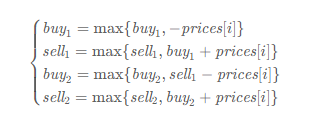

In [25]:
from typing import List
def maxProfit(prices: List[int]) -> int:
    
    buy1 = buy2 = -prices[0]
    sell1= sell2 = 0
    # print(f"{0},{buy1,sell1,buy2,sell2}")
    for i in range(1,len(prices)):
        buy1 = max(buy1,-prices[i])  # 买入
        sell1 = max(sell1, buy1+prices[i])
        buy2 = max(buy2, sell1-prices[i])  # # 第二次买入
        sell2 = max(sell2, buy2 + prices[i])
        # print(f"{i},{buy1,sell1,buy2,sell2}")
    
    return sell2

prices = [3,3,5,0,0,3,1,4]
prices = [1,2,3,4,5]
prices = [7,1,5,3,6,4]
maxProfit(prices)

7

### 1. 两数之和
>给定一个整数数组 nums 和一个整数目标值 target，请你在该数组中找出 和为目标值 target  的那 两个 整数，并返回它们的数组下标。

思路：最经典的题，使用哈希表实现。

In [30]:
def twoSum(nums: List[int], target: int) -> List[int]:
    hashMap = {}
    for i,num in enumerate(nums):
        if target-num in hashMap:
            return [hashMap[target-num],i]
        hashMap[num] = i
    print(hashMap)

nums = [3,2,4]
target = 6
twoSum(nums, target)

[1, 2]

### 122. 买卖股票的最佳时机 II
>给定一个数组，它的第 i 个元素是一支给定的股票在第 i 天的价格。可以是多笔交易的情况下，计算所能获取的最大利润。

- 思路：贪心算法。只和前一个比较。取dp表中大于0的相加，就是答案。下面做了空间优化

总结来说，买卖股票的最佳时机的I,II,III,第一个是DP解法，第二个是贪心+dp解法，第三个是buy1,sell1,buy2,sell2，返回sell2。

In [36]:
def maxProfit(prices: List[int]) -> int:
    """贪心"""
    # 初始化
    ans = 0
    for i in range(1,len(prices)):
        profit = prices[i]-prices[i-1]
        if profit > 0: ans+= profit
        
    return ans

prices = [7,1,5,3,6,4]
prices = [1,2,3,4,5]
maxProfit(prices)

4

### 141. 环形链表
> 判断链表是否有环, 返回 True or False。

思路：Floyd 判圈算法。初始时，慢指针在位置 head，而快指针在位置 head。慢指针每次只移动一步，而快指针每次移动两步。

拓展，如果有环找出入环节点。当快指针追上慢指针后，慢指针回到起点，慢指针每次只移动一步，快指针每次也移动一步，再次相遇就是入环点。

In [ ]:
from typing import Optional
class ListNode:
    def __init__(self, x):
        self.val = x
        self.next = None
def hasCycle(head: Optional[ListNode]) -> bool:
    slow, fast = head, head
    while fast and fast.next:
        slow = slow.next
        fast = fast.next.next
        if slow == fast:  # 快指针追上慢指针
            return True
    
    return False

### 142. 环形链表 II
> 给定一个链表的头节点  head ，返回链表开始入环的第一个节点。 如果链表无环，则返回 null。

- 思路：当快指针追上慢指针后，慢指针回到起点，慢指针每次只移动一步，快指针每次也移动一步，再次相遇就是入环点。

In [ ]:
def detectCycle(head: Optional[ListNode]) -> Optional[ListNode]:
    slow, fast = head, head
    while fast and fast.next:
        slow = slow.next
        fast = fast.next.next
        if slow == fast:  # 快指针追上慢指针
            slow = head
            while slow != head:
                slow = slow.next
                fast = fast.next
            
            return slow
    return None

### 148. 排序链表
> 给你链表的头结点 head, 请将其按 升序 排列并返回 排序后的链表。

思路：这题使用归并排序(递归实现)。需要两个辅助函数，findMid(head),mergeList(head1, head2)。

In [38]:
def findMid(head):
    "这里是链表，如果是数组，改变这个函数就好了。数组就是左+(左+右)/2"
    slow , fast = head, head.next
    while fast and fast.next :
        slow = slow.next
        fast = fast.next.next
    return slow
def mergeList(head1, head2):
    "合并两个有序链表"
    tail = dummy = ListNode()
    while head1  and head2 :
        if head1.val < head2.val:
            tail.next = head1
            head1 = head1.next
        else:
            tail.next = head2
            head2 = head2.next
        tail  = tail.next
    tail.next = head1 if head1  else head2

    return dummy.next
def sortList(head: Optional[ListNode]) -> Optional[ListNode]:
    if not head or not head.next:
        return head

    mid = findMid(head) 
    right = mid.next
    mid.next = None

    return mergeList(sortList(head),sortList(right)) 


### 32. 最长有效括号
> 给你一个只包含 '(' 和 ')' 的字符串，找出最长有效（格式正确且连续）括号子串的长度。

- 思路：动态规划。这种方法最容易记下来。最后的答案即为 dp 数组中的最大值。

In [46]:
def longestValidParentheses(s: str) -> int:
    dp = [0]*len(s)
    ans = 0
    for i in range(1,len(s)):
        if s[i] ==')':
            if s[i-1] == '(':
                dp[i] = (dp[i-2] if i>=2 else 0) + 2
            elif i-dp[i-1]>0 and s[i-dp[i-1]-1] == '(':
                dp[i] = dp[i-1] + (dp[i-dp[i-1]-2] if i-dp[i-1]>=2 else 0) + 2
            
            ans = max(ans, dp[i])
    print(dp)
        
    return ans

s = "())((())"
longestValidParentheses(s)

[0, 2, 0, 0, 0, 0, 2, 4]


4

- 使用栈这种数据结构。代码省略。

### 240. 搜索二维矩阵 II
> 编写一个高效的算法来搜索 m x n 矩阵 matrix 中的一个目标值 target 。

这题和74. 搜索二维矩阵 的不同点在于，缺少了每行的第一个整数大于前一行的最后一个整数。这个条件。其他条件一样. 可以用二分查找，但不是最优
- 思路1：直接查找，代码简单，时间复杂度高O(MN), 代码省略。
- 思路2：二分查找，对每行使用一次二分查找。用库bisect实现。时间复杂度O(mlogn)，代码省略。
- 思路3：Z 字形查找。从右上角 (0,n−1) 开始搜索，往左下角搜索。三种情况，当前的matrix[i][j] == target, matrix[i][j]<target, matrix[i][j]>target。超界就是搜索失败




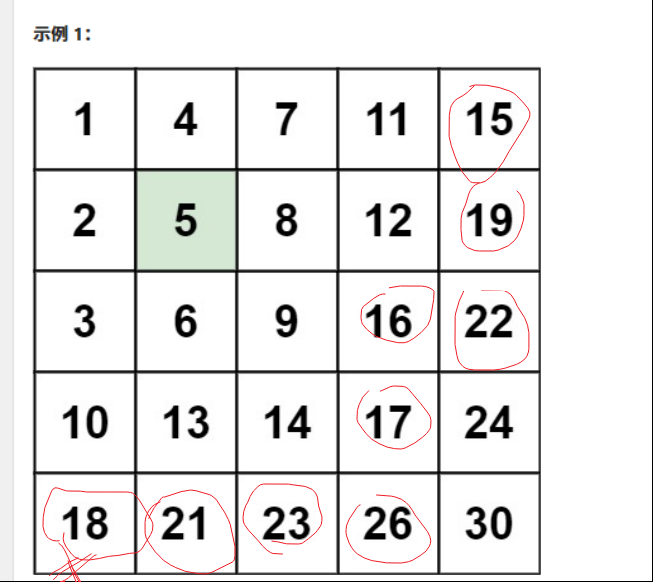

In [55]:
def searchMatrix(matrix: List[List[int]], target: int) -> bool:
    rows, columns = len(matrix), len(matrix[0])
    print(rows, columns)
    direction = [(0,-1), (1,0)]
    row,column = 0,columns-1  # 起点
    while row<rows and column >= 0:
        if matrix[row][column] == target:
            return True
        elif matrix[row][column] < target:
            row,column = row+direction[1][0], column+direction[1][1]
        else:
            row,column = row+direction[0][0], column+direction[0][1]
    return False

# matrix = [[1,4,7,11,15],[2,5,8,12,19],[3,6,9,16,22],[10,13,14,17,24],[18,21,23,26,30]]
matrix = [[-5]]
target = -5
searchMatrix(matrix, target)

1 1


True

### 43. 字符串相乘
> 给定两个以字符串形式表示的非负整数 num1 和 num2，返回 num1 和 num2 的乘积，它们的乘积也表示为字符串形式。不能使用内置函数。

- 思路：做乘法。这是一道数学题。num1[i]xnum2[j] = ansArr[i+j+1].从高位往低位写入。

0918 第一次遇到。

In [68]:
def multiply(num1: str, num2: str) -> str:
    if num1 == "0" or num2 == "0":
            return "0"
    
    m,n = len(num1),len(num2)
    ansArr = [0]*(m+n)
    for i in range(m-1,-1,-1):
        x = int(num1[i])
        for j in range(n-1,-1,-1):
            ansArr[i+j+1] += x*int(num2[j])
    
    print(ansArr)
    # post 拆分处理
    for i in range(m+n-1,0,-1):
        ansArr[i-1] += ansArr[i] // 10  #取出来10位
        ansArr[i] %= 10
    print(ansArr)
    idx = 1 if ansArr[0] == 0 else 0
    ans = ''.join(map(str,ansArr[idx:]))
    
    return ans
            

num1 = "1234"
num2 = "567"
multiply(num1, num2)

[0, 5, 16, 34, 52, 45, 28]
[0, 6, 9, 9, 6, 7, 8]


'699678'

### 48. 旋转图像
> 给定一个 n × n 的二维矩阵 matrix 表示一个图像。请你将图像顺时针旋转 90 度。原地旋转

- 思路：和旋转遍历有点像，但不是一个模版。

本题代码可以先背下来。代码很巧。无论n为奇数偶数都通用

In [76]:
def rotate(matrix: List[List[int]]) -> None:
    n = len(matrix)
    for i in range(n//2):
        for j in range((n+1)//2):
            tmp = matrix[i][j]
            matrix[i][j] =  matrix[n - j - 1][i]
            matrix[n - j - 1][i] = matrix[n - i - 1][n - j - 1]
            matrix[n - i - 1][n - j - 1] = matrix[j][n - i - 1]
            matrix[j][n - i - 1] = tmp
    
    # print(matrix)

matrix = [[5,1,9,11],[2,4,8,10],[13,3,6,7],[15,14,12,16]]
rotate(matrix)
matrix

[[15, 13, 2, 5], [14, 3, 4, 1], [12, 6, 8, 9], [16, 7, 10, 11]]

### 补充题：1886. 判断矩阵经轮转后是否一致
>给你两个大小为 n x n 的二进制矩阵 mat 和 target 。现 以 90 度顺时针轮转 矩阵 mat 中的元素 若干次 ，如果能够使 mat 与 target 一致，返回 true ；否则，返回 false 。

- 思路：模拟 4 次将 mat 90 度顺时针旋转的操作，并在每次旋转操作后与 target 比较。

直接用到了上面的rotate(matrix)函数。

In [80]:
def findRotation(mat: List[List[int]], target: List[List[int]]) -> bool:
    for _ in range(4):
        # 判断
        if target == mat:
            return True
        rotate(target)
    return False

mat = [[0,1],[1,0]]
target = [[1,0],[0,1]]
findRotation(mat,target)

True

什么是字典序？字典序更大的排列？字典序更小的排列？  
如[1,2,3], [3,2,1]。 "ABC"与"ACB"  

先比较第一个元素/字符，小的排前面,如果相等，再比较第二个元素/字符

### 31. 下一个排列
> 例如，arr = [1,2,3] ，以下这些都可以视作 arr 的排列：[1,2,3]、[1,3,2]、[3,1,2]、[2,3,1] 。整数数组的 下一个排列 是指其整数的下一个字典序更大的排列。原地修改。

- 思路：双指针解法。寻找非降序的nums[i], 寻找nums[j]并交换两者， 反转nums[i]后的元素。一共是这3步。

找未知用while, 虽然for 也能用，但要加break

In [102]:
def nextPermutation(nums: List[int]) -> None:
    
    i = len(nums) - 2
    # 找非降序的nums[i]
    while i >=0 and nums[i] >= nums[i+1]:
        i -= 1
    # 找nums[j]
    if i>=0:
        j = len(nums) - 1
        while j >=0 and nums[j] <= nums[i]:
            j -=1
        nums[i],nums[j] = nums[j],nums[i]
    left,right = i+1,len(nums)-1
    while left < right:
        nums[left],nums[right] = nums[right],nums[left]
        left += 1
        right -= 1

nums = [1,3,2]
nextPermutation(nums)
nums

[2, 1, 3]

### LCR 170. 交易逆序对的总数
> 在股票交易中，如果前一天的股价高于后一天的股价，则可以认为存在一个「交易逆序对」。请设计一个程序，输入一段时间内的股票交易记录 record，返回其中存在的「交易逆序对」总数。

- 思路：使用归并排序的模版。在并的过程中记下来逆序对。甚至最后对record数组完成了排序

本题近期没考察。


In [ ]:
def mergeSort(record, tmp, l, r):
        if l >= r:
            return 0

        mid = (l + r) // 2
        inv_count = mergeSort(record, tmp, l, mid) + mergeSort(record, tmp, mid + 1, r)
        # 开始 并
        i, j, pos = l, mid + 1, l
        while i <= mid and j <= r:
            if record[i] <= record[j]:
                tmp[pos] = record[i]
                i += 1
                inv_count += (j - (mid + 1))  # 这里算贡献
            else:
                tmp[pos] = record[j]
                j += 1
            pos += 1
        # 把后面的拼上
        for k in range(i, mid + 1):
            tmp[pos] = record[k]
            inv_count += (j - (mid + 1))
            pos += 1
        for k in range(j, r + 1):
            tmp[pos] = record[k]
            pos += 1
        # 辅助数组tmp 拷贝回原数组。
        record[l:r+1] = tmp[l:r+1]
        return inv_count

def reversePairs(record: List[int]) -> int:
    n = len(record)
    tmp = [0] * n
    return mergeSort(record, tmp, 0, n - 1)   

record = [9, 7, 5, 4, 6]
reversePairs(record)

[4, 5, 6, 7, 9]
[4, 5, 6, 7, 9]


8

### 560. 和为 K 的子数组
>给你一个整数数组 nums 和一个整数 k ，请你统计并返回 该数组中和为 k 的子数组的个数。子数组是数组中元素的连续非空序列。

- 思路：前缀和，在原数组的最前面加一个数组0，这样就可以通过prefix[j]-prefix[i] 得到元素i+1 到元素j 的和。一次正向遍历就能解决


dict.get(key, default) 先安全地取值，不存在则返回 default。

本题是小红书的笔试原题。

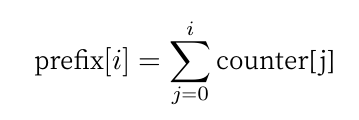

In [10]:
hashMap = {}
hashMap[4] = hashMap.get(4,0) + 1
hashMap[4] = hashMap.get(4,0) + 1
hashMap[4] = hashMap.get(4,0) + 1
hashMap

{4: 3}

In [24]:
from typing import List
def subarraySum(nums: List[int], k: int) -> int:
    n = len(nums)
    # hashMap,存储每个前缀和出现的次数
    # prefix = [0]*(n+1)
    prefix = 0
    hashMap = {0:1}
    count = 0
    for i in range(n):
        prefix += nums[i]
        if prefix-k in hashMap:
            count += hashMap[prefix-k]
        hashMap[prefix] = hashMap.get(prefix ,0) + 1
    print(prefix)
    print(hashMap)
    return count

# nums = [1,2,3]
nums = [3,4,7,2,-3,1,4,2]
nums = [1,-1,0]
k = 0
subarraySum(nums,k)

0
{0: 3, 1: 1}


3

### 19. 删除链表的倒数第 N 个结点
> 给你一个链表，删除链表的倒数第 n 个结点，并且返回链表的头结点。

思路：初始时 fast 和 slow 均指向头节点。我们首先使用 fast 对链表进行遍历，遍历的次数为 n。

注意：头结点可能被删除，所以用dummy

In [ ]:
def removeNthFromEnd(head: Optional[ListNode], n: int) -> Optional[ListNode]:
    dummy = ListNode(next = head)
    slow = fast = dummy
    while n:
        fast = fast.next
        n-=1
    while fast.next:
        slow = slow.next
        fast = fast.next
    # delete 操作
    slow.next = slow.next.next
    return dummy.next

### 62. 不同路径
>一个机器人位于一个 m x n 网格的左上角 ,他走到右下角有多少种不同的路径。

思路：二维DP，首行首列为1

拓展，如果有障碍怎么办？

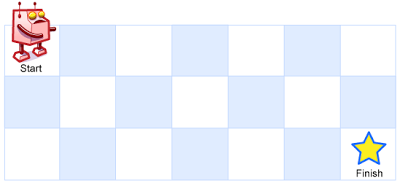

In [ ]:
def uniquePaths(self, m: int, n: int) -> int:
    pass